In [103]:
# legacy_enriching_v1 — CELL 1: Setup and load structural ROIs

import pandas as pd
from pathlib import Path

BASE    = Path("/Users/davekokel/Projects/carp_v2")
WORKING = BASE / "seed_kits" / "legacy_wrangling" / "working"
AUTOLOAD = BASE / "seed_kits" / "2025-11-15-121231-autoload"

struct_path = WORKING / "legacy_roi_structural_v1.csv"
df = pd.read_csv(struct_path)

df.shape, df.columns.tolist()
df.head()

,date_experiment,fish,roi_rel,roi_name,roi_tiffs,roi_dir,dataset,date_mount,mount_id,ZF female genotype,...,Mounting Orientation,Date screened/Initial feedback,Date imaged,Time placed in scope,Start of imaging time,End of imaging time,Imaged Locations,Unique Targets with blanks,Unique Targets,Data location
0,20250428_mem_histone,fish1_72hpf,roi1_tail,roi1_tail,3206,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,2025-11-12,1,casper,...,DH,NaN,2025-11-12,NaN,NaN,NaN,"skin, spinal_cord, hindbrain, brain, muscle, b...",NaN,NaN,X:\abcabc\Korra_Foundation\20251112_mem-mito
1,20250428_mem_histone,fish1_72hpf,roi2_hindbrain_spine,roi2_hindbrain_spine,9760,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,2025-11-12,2,casper,...,DH,NaN,2025-11-12,NaN,NaN,NaN,NaN,NaN,NaN,X:\abcabc\Exploratory_fish\20251112_mem-moesin
2,20250429_mem_cytosol,fish1_24hpf,roi1,roi1,6873,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,2025-11-11,1,casper,...,DH,NaN,2025-11-11,NaN,NaN,NaN,"skin, spinal_cord, hindbrain, brain, muscle",NaN,NaN,X:\abcabc\Aang_Foundation\20251107_mem-mito
3,20250429_mem_cytosol,fish1_24hpf,roi1_test,roi1_test,46,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,2025-11-10,1,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),...,DH,NaN,2025-11-10,NaN,NaN,NaN,"skin, spinal_cord, hindbrain, brain, muscle, b...",NaN,NaN,X:\abcabc\Korra_Foundation\20251110_mem-histone
4,20250429_mem_cytosol,fish2_48hpf,roi1,roi1,3180,/clusterfs/vast/abcabc/Korra_Foundation/202504...,korra,2025-11-06,1.1,casper,...,DH,NaN,2025-11-06,NaN,NaN,NaN,"skin, spinal_cord, hindbrain, brain, muscle",NaN,NaN,X:\abcabc\Aang_Foundation\20251106_mem-mito


In [104]:
# CELL 2: Load fish registry, constructs, and tags from autoload kit

fish_path       = AUTOLOAD / "fish.xlsx"
constructs_path = AUTOLOAD / "constructs_plasmid.csv"
tags_path       = AUTOLOAD / "tags.xlsx"

df_fish       = pd.read_excel(fish_path)
df_constructs = pd.read_csv(constructs_path)
df_tags       = pd.read_excel(tags_path)

df_fish.shape, df_constructs.shape, df_tags.shape

((122, 9), (286, 12), (10, 5))

In [105]:
# CELL 3: Fish nickname -> transgene mapping (allow multiple transgenes per nickname)

import pandas as pd

fish_df = df_fish.copy()
fish_df["nickname"] = fish_df["nickname"].astype(str).str.strip()

# Keep only the columns we care about
fish_core = fish_df[["nickname", "transgene_base_code", "allele_nickname"]].dropna(
    subset=["nickname", "transgene_base_code"]
)

# Group by nickname to handle duplicates
def join_unique(series: pd.Series) -> str:
    vals = [str(x).strip() for x in series if pd.notna(x) and str(x).strip()]
    if not vals:
        return ""
    uniq = sorted(set(vals))
    return ",".join(uniq)

fish_grouped = (
    fish_core
    .groupby("nickname", as_index=True)
    .agg(
        transgene_base_code=("transgene_base_code", join_unique),
        allele_nickname=("allele_nickname", join_unique),
    )
)

# Build lookup dict: nickname -> {"transgene_base_code": "...", "allele_nickname": "..."}
fish_lookup = fish_grouped.to_dict(orient="index")

print("fish_lookup nicknames:", len(fish_lookup))
fish_grouped.head()

fish_lookup nicknames: 54


,transgene_base_code,allele_nickname
nickname,,
Abe (F2 of allele 309),pDQM034,309
Ben (F2 of allele 310),pDQM034,310
CDK activity sensor (ef1a-ext:DHB:tdmStayGold),pDQM155,
Chris (F1 of allele 317),pDQM034,317
Dennis (F2 of allele 318),pDQM036,318


In [106]:
# CELL 3a: Load parent name mapping (legacy_wrangling/raw)

from pathlib import Path
import pandas as pd
import math

BASE    = Path("/Users/davekokel/Projects/carp_v2")
RAW     = BASE / "seed_kits" / "legacy_wrangling" / "raw"

parent_map_path = RAW / "Unique_parent_names__mom_dad_combined__preview_dqm.xlsx"
df_parent_map = pd.read_excel(parent_map_path)

print("df_parent_map:", df_parent_map.shape)
print(df_parent_map.columns.tolist())
df_parent_map.head()

df_parent_map: (41, 3)
['parent_fish_name', 'plasmid_base_code', 'allele']


,parent_fish_name,plasmid_base_code,allele
0,tandem mem:mStayGold,pDQM005,301
1,ef1a:2xLynk:tdmSG(J) (F1 of allele 302),pDQM005,302
2,casper/rnf,NaN,NaN
3,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,315
4,tdmScarlet3S2 (F1 of allele 325),pDQM136,325


In [107]:
# CELL 3b: Build parent -> (plasmid_base_code, allele) lookup from df_parent_map

# normalize the parent_fish_name strings
df_parent_map["parent_fish_name"] = df_parent_map["parent_fish_name"].astype(str).str.strip()

# parent_genotype_lookup: parent_fish_name -> {"plasmid_base_code": ..., "allele": ...}
parent_genotype_lookup = (
    df_parent_map
    .set_index("parent_fish_name")
    .to_dict(orient="index")
)

print("parent_genotype_lookup entries:", len(parent_genotype_lookup))
list(parent_genotype_lookup.items())[:5]

parent_genotype_lookup entries: 41


[('tandem mem:mStayGold', {'plasmid_base_code': 'pDQM005', 'allele': 301}),
 ('ef1a:2xLynk:tdmSG(J) (F1 of allele 302)',
  {'plasmid_base_code': 'pDQM005', 'allele': 302}),
 ('casper/rnf', {'plasmid_base_code': nan, 'allele': nan}),
 ('ef1a:2xLynk:tdmChilada (F1 of allele 315)',
  {'plasmid_base_code': 'pDQM082', 'allele': 315}),
 ('tdmScarlet3S2 (F1 of allele 325)',
  {'plasmid_base_code': 'pDQM136', 'allele': 325})]

In [108]:
## CELL 4: Normalize parent columns from imaging sheet

import math

def norm_text(val):
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return None
    s = str(val).strip()
    return s or None

df["parent_female"] = df["ZF female genotype"].apply(norm_text)
df["parent_male"]   = df["ZF male genotype"].apply(norm_text)

df[["roi_dir", "parent_female", "parent_male"]].head(20)

,roi_dir,parent_female,parent_male
0,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,memrane tdmScarlet3S2 (F1 of allele 325)
1,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,memrane tdmScarlet3S2 (F1 of allele 325)
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,memrane tdmScarlet3S2 (F1 of allele 325)
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324)
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315)
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315)
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315)
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,ef1a:2xLynk:tdmSG(J) (F1 of allele 302),tdmScarlet3S2:H2B-tol2 (F1 of allele 324)
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper/rnf,memrane tdmScarlet3S2 (F1 of allele 325)
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper/rnf,memrane tdmScarlet3S2 (F1 of allele 325)


In [109]:
# CELL 5: Infer genotype_base_codes and genotype_allele_codes from parents

def is_blank(val: object) -> bool:
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    return str(val).strip() == ""

def fill_genotype_from_parents(row: pd.Series) -> pd.Series:
    # do not overwrite existing genotype_base_codes
    if not is_blank(row.get("genotype_base_codes", None)):
        return row

    for parent_col in ("parent_female", "parent_male"):
        parent = row.get(parent_col)
        if parent is None or pd.isna(parent):
            continue
        key = str(parent).strip()

        # 1) first try the parent_genotype_lookup from df_parent_map
        if key in parent_genotype_lookup:
            info = parent_genotype_lookup[key]
            base   = info.get("plasmid_base_code")
            allele = info.get("allele")

            if not is_blank(base):
                row["genotype_base_codes"] = str(base).strip()
                # build allele code if we have an allele
                if not is_blank(allele):
                    row["genotype_allele_codes"] = f"{base}:{allele}"
                break

        # 2) fall back to fish_lookup if parent not in parent_genotype_lookup
        if key in fish_lookup:
            info = fish_lookup[key]
            base   = info["transgene_base_code"]
            allele = info["allele_nickname"]
            row["genotype_base_codes"]   = base
            row["genotype_allele_codes"] = allele or None
            break

    return row

df = df.apply(fill_genotype_from_parents, axis=1)

df[["roi_dir", "parent_female", "parent_male",
    "genotype_base_codes", "genotype_allele_codes"]].head(20)

,roi_dir,parent_female,parent_male,genotype_base_codes,genotype_allele_codes
0,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,memrane tdmScarlet3S2 (F1 of allele 325),pDQM136,pDQM136:325
1,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,memrane tdmScarlet3S2 (F1 of allele 325),pDQM136,pDQM136:325
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,memrane tdmScarlet3S2 (F1 of allele 325),pDQM136,pDQM136:325
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),pDQM005,pDQM005:301
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,ef1a:2xLynk:tdmSG(J) (F1 of allele 302),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),pDQM005,pDQM005:302
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper/rnf,memrane tdmScarlet3S2 (F1 of allele 325),pDQM136,pDQM136:325
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,casper/rnf,memrane tdmScarlet3S2 (F1 of allele 325),pDQM136,pDQM136:325


In [110]:
# CELL 6: Load injected plasmid and RNA mapping tables

from pathlib import Path
import pandas as pd
import math

BASE    = Path("/Users/davekokel/Projects/carp_v2")
RAW     = BASE / "seed_kits" / "legacy_wrangling" / "raw"

inj_plasmid_path = RAW / "Unique_injected_plasmid__preview_dqm.xlsx"
inj_rna_path     = RAW / "Unique_injected_rna__preview_dqm.xlsx"

df_inj_plasm = pd.read_excel(inj_plasmid_path)
df_inj_rna   = pd.read_excel(inj_rna_path)

print("df_inj_plasm:", df_inj_plasm.shape)
print(df_inj_plasm.columns.tolist())
print("df_inj_rna:", df_inj_rna.shape)
print(df_inj_rna.columns.tolist())

df_inj_plasm.head(), df_inj_rna.head()

df_inj_plasm: (25, 2)
['injected_plasmid', 'plasmid_base_code']
df_inj_rna: (44, 2)
['injected_rna', 'plasmid_base_code']


(                                    injected_plasmid  \
 0                  ef1a-extended:2xCox8A:mScarlet3S2   
 1                         ef1a-extended:2xCox8A:Halo   
 2                                             MGCO34   
 3  Skittles-lite (ef1a:mTFP1 / ef1a:mChilada / ef...   
 4                                            MGCO-55   
 
            plasmid_base_code  
 0                    MGCO-35  
 1                    MGCO-39  
 2                    MGCO-34  
 3  pDQM087, pDQM089, pDQM106  
 4                    MGCO-55  ,
                                   injected_rna          plasmid_base_code
 0                          2xCox8A:mScarlet3S2                    MGCO-35
 1                                  2xCox8A:mSG                    MGCO-01
 2                2xCox8A:mSG,, 2xLynk:mChilada           MGCO-35, pDQM092
 3                 2xLynk:mChilada,, 2xLynk:mSG           pDQM092, pDQM047
 4  2xLynk:mChilada,, 2xLynk:mSG,, Lifeact:Halo  pDQM092, pDQM047, MGCO-24)

In [111]:
# CELL 6c: Load Janelia plasmid sheet (extra mapping source)

from pathlib import Path
import pandas as pd

BASE    = Path("/Users/davekokel/Projects/carp_v2")
RAW     = BASE / "seed_kits" / "legacy_wrangling" / "raw"

jrc_path = RAW / "plasmids_janelia_googlesheet.xlsx"
df_jrc = pd.read_excel(jrc_path)

print("df_jrc:", df_jrc.shape)
print(df_jrc.columns.tolist())
df_jrc.head()

df_jrc: (65, 6)
['ID', 'Name', 'Marker', 'Organelle\xa0', 'Nickname (if needed)', 'Resistance']


,ID,Name,Marker,Organelle,Nickname (if needed),Resistance
0,MGCO-01,ef1a-2Xcox8A-linker-mStayGold-SV40-attb-tol2,mStayGold,Mitochondria,2xcox8A-mStayGold,Amp
1,MGCO-02,ef1a-2Xcox8A-linker-mChilada-SV40-attb-tol2,mChilada,Mitochondria,2xcox8A-mChilada,Amp
2,MGCO-03,ef1a-2Xcox8A-linker-Halo-SV40-attb-tol2,Halo,Mitochondria,2xcos8A-Halo,Amp
3,MGCO-04,ef1a-linker-mStayGold-C4linker-sec61b-SV40-att...,mStayGold,ER,mStayGold-sec61b,Amp
4,MGCO-05,ef1a-linker-mChilada-C4linker-sec61b-SV40-attb...,mChilada,ER,mChilada-sec61b,Amp


In [112]:
# CELL 7: Map "additional plasmids/mRNAs injected" -> treatment base codes
# using Unique_injected_plasmid, Unique_injected_rna, and Janelia plasmid sheet

import re
import math

# --- helper to split free-text injections from imaging sheet -----------------

def normalize_inj_text(text: object) -> list[str]:
    """Split the 'additional plasmids/mRNAs injected' free text into cleaned tokens."""
    if text is None or (isinstance(text, float) and math.isnan(text)):
        return []
    s = str(text).strip()
    if not s:
        return []
    # split on common delimiters ; ,
    tokens = re.split(r"[;,]", s)
    return [t.strip() for t in tokens if t.strip()]


# =============================================================================
# 1) Build plasmid injection map: inj_plasm_map
# =============================================================================

PLASM_RAW_COL  = "injected_plasmid"    # from df_inj_plasm
PLASM_BASE_COL = "plasmid_base_code"   # from df_inj_plasm

pl = df_inj_plasm.copy()
pl[PLASM_RAW_COL]  = pl[PLASM_RAW_COL].astype(str).str.strip()
pl[PLASM_BASE_COL] = pl[PLASM_BASE_COL].astype(str).str.strip()

inj_plasm_map = {}
for _, row in pl.iterrows():
    raw = row[PLASM_RAW_COL]
    base = row[PLASM_BASE_COL]
    if not raw:
        continue
    if raw not in inj_plasm_map:
        inj_plasm_map[raw] = []
    if base and base not in inj_plasm_map[raw]:
        inj_plasm_map[raw].append(base)

# collapse to strings
inj_plasm_map = {k: ",".join(v) for k, v in inj_plasm_map.items()}


# =============================================================================
# 2) Build RNA injection map from Unique_injected_rna (single-construct rows only)
# =============================================================================

RNA_RAW_COL  = "injected_rna"          # from df_inj_rna
RNA_BASE_COL = "plasmid_base_code"     # from df_inj_rna

rn = df_inj_rna.copy()
rn[RNA_RAW_COL]  = rn[RNA_RAW_COL].astype(str).str.strip()
rn[RNA_BASE_COL] = rn[RNA_BASE_COL].astype(str).str.strip()

inj_rna_map = {}

for _, row in rn.iterrows():
    raw  = row[RNA_RAW_COL]
    base = row[RNA_BASE_COL]
    if not raw or not base:
        continue

    # 🚫 Ignore composite mappings like "2xCox8A:mSG,, 2xLynk:mChilada"
    # We only want rows where injected_rna is a single construct.
    if ",," in raw:
        continue

    if raw not in inj_rna_map:
        inj_rna_map[raw] = set()
    inj_rna_map[raw].add(base)


# =============================================================================
# 3) Extend RNA injection map with Janelia plasmid sheet
# =============================================================================

# JRC columns: ['ID', 'Name', 'Marker', 'Organelle\xa0', 'Nickname (if needed)', 'Resistance']
JRC_ID_COL    = "ID"
JRC_NAME_COLS = ["Nickname (if needed)", "Name", "Marker"]

jrc = df_jrc.copy()

for _, row in jrc.iterrows():
    base = str(row[JRC_ID_COL]).strip()
    if not base:
        continue

    for col in JRC_NAME_COLS:
        if col not in jrc.columns:
            continue
        raw = row[col]
        if raw is None or (isinstance(raw, float) and math.isnan(raw)):
            continue
        name = str(raw).strip()
        if not name:
            continue

        tokens = re.split(r"[;,]", name)
        tokens = [t.strip() for t in tokens if t.strip()]

        for tok in tokens:
            if not tok:
                continue
            if tok not in inj_rna_map:
                inj_rna_map[tok] = set()
            inj_rna_map[tok].add(base)

            # also try colon-style alias if name uses '-' or spaces: "mChilada-H2B" -> "mChilada:H2B"
            alt = tok.replace("-", ":").replace(" ", "")
            if alt != tok:
                if alt not in inj_rna_map:
                    inj_rna_map[alt] = set()
                inj_rna_map[alt].add(base)

# collapse RNA map sets to comma-joined strings
inj_rna_map = {k: ",".join(sorted(v)) for k, v in inj_rna_map.items()}


# =============================================================================
# 4) Mapping functions: text -> base_code strings
# =============================================================================

def map_plasmids(text: object) -> str | None:
    tokens = normalize_inj_text(text)
    bases = []
    for t in tokens:
        # 1) exact match
        if t in inj_plasm_map:
            for code in inj_plasm_map[t].split(","):
                c = code.strip()
                if c and c not in bases:
                    bases.append(c)
            continue

        # 2) try stripping annotation in parentheses: 'MGCO-01(...)' -> 'MGCO-01'
        m = re.match(r"^([A-Za-z0-9\-]+)\s*\(", t)
        if m:
            prefix = m.group(1)
            if prefix in inj_plasm_map:
                for code in inj_plasm_map[prefix].split(","):
                    c = code.strip()
                    if c and c not in bases:
                        bases.append(c)
                continue

        # 3) allow raw 'MGCO-01' even if not in inj_plasm_map, as its own base code
        m2 = re.match(r"^(MGCO-\d+)", t)
        if m2:
            base = m2.group(1)
            if base not in bases:
                bases.append(base)

    return ",".join(bases) if bases else None

def map_rnas(text: object) -> str | None:
    tokens = normalize_inj_text(text)
    bases = []
    for t in tokens:
        if t in inj_rna_map:
            for code in inj_rna_map[t].split(","):
                c = code.strip()
                if c and c not in bases:
                    bases.append(c)
            continue
    return ",".join(bases) if bases else None


# =============================================================================
# 5) Apply mapping to df to fill treatment_plasmid_base_codes / treatment_rna_base_codes
# =============================================================================

PLASM_INJ_COL = "additional plasmids injected"
RNA_INJ_COL   = "additional mRNAs injected"

df["treatment_plasmid_base_codes"] = df[PLASM_INJ_COL].apply(map_plasmids)
df["treatment_rna_base_codes"]     = df[RNA_INJ_COL].apply(map_rnas)

df[[ "roi_dir",
     PLASM_INJ_COL,
     RNA_INJ_COL,
     "treatment_plasmid_base_codes",
     "treatment_rna_base_codes"]].head(20)

,roi_dir,additional plasmids injected,additional mRNAs injected,treatment_plasmid_base_codes,treatment_rna_base_codes
0,/clusterfs/vast/abcabc/Korra_Foundation/202504...,MGCO-01(ef1a-2Xcox8A-linker-mStayGold-SV40-att...,NaN,MGCO-01,None
1,/clusterfs/vast/abcabc/Korra_Foundation/202504...,MGCO-60-Factin-A2UCOE-attb_entire+PDQM148-mSta...,NaN,MGCO-60,None
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,MGCO-01(ef1a-2Xcox8A-linker-mStayGold-SV40-att...,NaN,MGCO-01,None
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,NaN,NaN,None,None
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,NaN,2xCox8A:mSG,None,MGCO-01
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,NaN,2xCox8A:mSG,None,MGCO-01
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,NaN,2xCox8A:mSG,None,MGCO-01
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,NaN,2xCox8A:mSG,None,MGCO-01
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,MGCO-49_peroxisome-A2UCOE-ef1aextra-mStayGold-SKL,NaN,MGCO-49,None
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,NaN,2xCox8A:mSG,None,MGCO-01


In [113]:
# CELL7a : Diagnose remaining treatment holes and their injection strings

def is_blank(val: object) -> bool:
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    return str(val).strip() == ""

# rows where BOTH treatment base-code fields are blank
mask_treat_hole = (
    df["treatment_plasmid_base_codes"].apply(is_blank) &
    df["treatment_rna_base_codes"].apply(is_blank)
)

holes = df.loc[mask_treat_hole].copy()

print("Total ROIs:", len(df))
print("ROIs with no treatment base codes:", len(holes))

# look at the raw injection fields for these holes
cols = [
    "roi_dir",
    "additional plasmids injected",
    "additional mRNAs injected",
]
display(holes[cols].head(50))

Total ROIs: 976
ROIs with no treatment base codes: 716


,roi_dir,additional plasmids injected,additional mRNAs injected
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,NaN,NaN
12,/clusterfs/vast/abcabc/Korra_Foundation/202505...,NaN,NaN
13,/clusterfs/vast/abcabc/Korra_Foundation/202505...,NaN,NaN
16,/clusterfs/vast/abcabc/Korra_Foundation/202505...,NaN,NaN
18,/clusterfs/vast/abcabc/Korra_Foundation/202505...,NaN,NaN
20,/clusterfs/vast/abcabc/Korra_Foundation/202505...,NaN,NaN
23,/clusterfs/vast/abcabc/Korra_Foundation/202505...,NaN,NaN
24,/clusterfs/vast/abcabc/Korra_Foundation/202505...,NaN,NaN
27,/clusterfs/vast/abcabc/Korra_Foundation/202505...,NaN,NaN
29,/clusterfs/vast/abcabc/Korra_Foundation/202505...,NaN,NaN


In [114]:
# CELL 7b — List unmapped injection tokens (missing_plasmid_tokens / missing_rna_tokens)

missing_plasmid_tokens = set()
missing_rna_tokens = set()

for _, row in holes.iterrows():
    plasm_txt = row.get("additional plasmids injected")
    rna_txt   = row.get("additional mRNAs injected")

    # same normalize_inj_text we used in mapping cell
    plasm_tokens = normalize_inj_text(plasm_txt)
    rna_tokens   = normalize_inj_text(rna_txt)

    for t in plasm_tokens:
        if t not in inj_plasm_map:
            missing_plasmid_tokens.add(t)

    for t in rna_tokens:
        if t not in inj_rna_map:
            missing_rna_tokens.add(t)

print("Unmapped plasmid injection tokens:")
for t in sorted(missing_plasmid_tokens):
    print("  ", repr(t))

print("\nUnmapped RNA injection tokens:")
for t in sorted(missing_rna_tokens):
    print("  ", repr(t))

Unmapped plasmid injection tokens:

Unmapped RNA injection tokens:
   '2xLynk:mChilada'
   '2xLynk:mSG'
   'Lifeact:Halo'
   'mChilada:H2B'


In [115]:
# cell 8 Build constructs mapping (plasmid_base_code -> fluor/tag/tag_pos)
cons_small = (
    df_constructs[["plasmid_code", "fluor_code", "tag_code", "tag_pos"]]
    .rename(columns={"plasmid_code": "plasmid_base_code"})
    .copy()
)
cons_small["plasmid_base_code"] = cons_small["plasmid_base_code"].astype(str).str.strip()

# Build tags mapping (tag_code -> localization)
if "tag_code" in df_tags.columns:
    tag_code_col = "tag_code"
elif "nickname" in df_tags.columns:
    tag_code_col = "nickname"
else:
    raise RuntimeError("No tag_code or nickname column in tags.xlsx")

loc_cols = [c for c in df_tags.columns if c.lower() == "localization"]
if not loc_cols:
    raise RuntimeError("No localization column in tags.xlsx")
loc_col = loc_cols[0]

tags_map = df_tags[[tag_code_col, loc_col]].copy()
tags_map.columns = ["tag_code", "localization"]
tags_map["tag_code"] = tags_map["tag_code"].astype(str).str.strip()

In [116]:
# cell 9 ### **Common helpers for fusions/localizations**
import re
import pandas as pd
import math

def split_codes(val: object) -> list[str]:
    if val is None or pd.isna(val):
        return []
    s = str(val).strip()
    if not s:
        return []
    return [c.strip() for c in re.split(r"[;,]", s) if c.strip()]

def agg_uniq(series: pd.Series) -> str | None:
    vals = []
    for x in series:
        if x is None or pd.isna(x):
            continue
        s = str(x).strip()
        if not s:
            continue
        vals.append(s)
    if not vals:
        return None
    uniq = sorted(set(" ".join(s.split()) for s in vals))
    return ",".join(uniq)

def make_fusion_label(row: pd.Series) -> str | None:
    def norm(val: object) -> str:
        if val is None or pd.isna(val):
            return ""
        return str(val).strip()
    fluor = norm(row.get("fluor_code"))
    tag   = norm(row.get("tag_code"))
    pos   = norm(row.get("tag_pos"))
    if not fluor and not tag:
        return None
    if fluor and not tag:
        return fluor
    if not fluor and tag:
        return tag
    if fluor and tag and pos:
        return f"{fluor}::{tag}({pos})"
    return f"{fluor}::{tag}"

def fluor_loc_label(row: pd.Series) -> str | None:
    def norm(val: object) -> str:
        if val is None or pd.isna(val):
            return ""
        return str(val).strip()
    fluor = norm(row.get("fluor_code"))
    loc   = norm(row.get("localization"))
    if not fluor:
        return None
    if loc:
        return f"{fluor}({loc})"
    return fluor

def fusion_loc_label(row: pd.Series) -> str | None:
    fusion = make_fusion_label(row)
    if not fusion:
        return None
    loc = row.get("localization")
    if loc is None or pd.isna(loc) or str(loc).strip() == "":
        return fusion
    return f"{fusion}({str(loc).strip()})"

In [117]:
# cell 10 Genotype fusions + localizations + fluor_loc/fusion_loc

gexp = (
    df[["roi_dir", "genotype_base_codes"]]
    .dropna(subset=["genotype_base_codes"])
    .assign(code_list=lambda d: d["genotype_base_codes"].apply(split_codes))
    .explode("code_list")
    .rename(columns={"code_list": "plasmid_base_code"})
)
gexp["plasmid_base_code"] = gexp["plasmid_base_code"].astype(str).str.strip()

gjoin = gexp.merge(cons_small, how="left", on="plasmid_base_code")
gjoin_loc = gjoin.merge(tags_map, how="left", on="tag_code")

gjoin_loc["fusion_label"] = gjoin_loc.apply(make_fusion_label, axis=1)
gjoin_loc["fluor_loc"]    = gjoin_loc.apply(fluor_loc_label, axis=1)
gjoin_loc["fusion_loc"]   = gjoin_loc.apply(fusion_loc_label, axis=1)

g_per_roi = (
    gjoin_loc.groupby("roi_dir", as_index=False)
    .agg(
        genotype_marker_fusion_labels     = ("fusion_label", agg_uniq),
        genotype_marker_localizations     = ("localization", agg_uniq),
        genotype_marker_fluor_loc_labels  = ("fluor_loc", agg_uniq),
        genotype_marker_fusion_loc_labels = ("fusion_loc", agg_uniq),
    )
)

df = df.merge(g_per_roi, how="left", on="roi_dir")

In [118]:
# cell 11 Treatment fusions + localizations + fluor_loc/fusion_loc

def collect_all_treatment_codes(row: pd.Series) -> list[str]:
    codes: list[str] = []
    codes.extend(split_codes(row.get("treatment_plasmid_base_codes")))
    codes.extend(split_codes(row.get("treatment_rna_base_codes")))
    seen = set()
    out: list[str] = []
    for c in codes:
        if c not in seen:
            seen.add(c)
            out.append(c)
    return out

texp = (
    df[["roi_dir", "treatment_plasmid_base_codes", "treatment_rna_base_codes"]]
    .assign(code_list=lambda d: d.apply(collect_all_treatment_codes, axis=1))
    .explode("code_list")
)

texp = texp[texp["code_list"].notna() & (texp["code_list"].astype(str).str.strip() != "")]
texp = texp.rename(columns={"code_list": "plasmid_base_code"})
texp["plasmid_base_code"] = texp["plasmid_base_code"].astype(str).str.strip()

tjoin = texp.merge(cons_small, how="left", on="plasmid_base_code")
tjoin_loc = tjoin.merge(tags_map, how="left", on="tag_code")

tjoin_loc["fusion_label"] = tjoin_loc.apply(make_fusion_label, axis=1)
tjoin_loc["fluor_loc"]    = tjoin_loc.apply(fluor_loc_label, axis=1)
tjoin_loc["fusion_loc"]   = tjoin_loc.apply(fusion_loc_label, axis=1)

t_per_roi = (
    tjoin_loc.groupby("roi_dir", as_index=False)
    .agg(
        treatment_marker_fusion_labels     = ("fusion_label", agg_uniq),
        treatment_marker_localizations     = ("localization", agg_uniq),
        treatment_marker_fluor_loc_labels  = ("fluor_loc", agg_uniq),
        treatment_marker_fusion_loc_labels = ("fusion_loc", agg_uniq),
    )
)

df = df.merge(t_per_roi, how="left", on="roi_dir")

In [119]:
# CELL 11b: Patch treatment_marker_localizations using Janelia Organelle when missing

import math
import re

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    return str(val).strip() == ""

# Build a mapping from base code (ID) -> Organelle (normalized)
jrc = df_jrc.copy()

# Clean the Organelle column (strip non-breaking space and whitespace)
org_col_candidates = [c for c in jrc.columns if "Organelle" in c]
if not org_col_candidates:
    raise RuntimeError("No Organelle column found in df_jrc")
ORG_COL = org_col_candidates[0]

jrc[ORG_COL] = jrc[ORG_COL].astype(str).str.replace("\u00a0", " ").str.strip()
jrc["ID"]    = jrc["ID"].astype(str).str.strip()

jrc_org_by_id = (
    jrc[["ID", ORG_COL]]
    .dropna(subset=[ORG_COL])
    .set_index("ID")[ORG_COL]
    .to_dict()
)

def fill_treatment_loc_from_jrc(row: pd.Series) -> str | None:
    """If treatment_marker_localizations is blank, use JRC Organelle as a fallback."""
    current = row.get("treatment_marker_localizations")
    if not is_blank(current):
        return current

    bases = str(row.get("treatment_plasmid_base_codes") or "").strip()
    if not bases:
        return None

    locs = []
    for base in re.split(r"[;,]", bases):
        b = base.strip()
        if not b:
            continue
        if b in jrc_org_by_id:
            loc = jrc_org_by_id[b]
            if loc and loc not in locs:
                locs.append(loc)

    return ",".join(sorted(set(locs))) if locs else None

df["treatment_marker_localizations"] = df.apply(
    lambda r: fill_treatment_loc_from_jrc(r), axis=1
)

# quick sanity check for MGCO-10 rows
mask_mgco10 = df["treatment_plasmid_base_codes"].fillna("").str.contains("MGCO-10")
df.loc[mask_mgco10, [
    "roi_dir",
    "treatment_plasmid_base_codes",
    "treatment_marker_fusion_labels",
    "treatment_marker_localizations"
]].head(10)

,roi_dir,treatment_plasmid_base_codes,treatment_marker_fusion_labels,treatment_marker_localizations


In [120]:
# CELL 12: Recompute all_unique_organelles from localizations + paths (roi_dir + Data location)

import re
import math
import pandas as pd

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    return str(val).strip() == ""

def split_locs(val: object) -> list[str]:
    """Split comma/semicolon-separated localization strings into tokens."""
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return []
    s = str(val).strip()
    if not s:
        return []
    s = s.replace(";", ",")
    return [p.strip() for p in s.split(",") if p.strip()]

def infer_organelles_from_paths(row: pd.Series) -> list[str]:
    """
    Infer organelle-ish labels from both roi_dir and Data location.
    Looks for 'mem_', 'mem-', 'mito', 'histone', 'peroxi', 'er'.
    """
    organelles: list[str] = []
    for col in ["roi_dir", "Data location"]:
        p = row.get(col)
        if p is None or (isinstance(p, float) and math.isnan(p)):
            continue
        s = str(p).lower()
        if "mem_" in s or "mem-" in s or "mem " in s:
            organelles.append("membrane")
        if "mito" in s:
            organelles.append("mitochondria")
        if "histone" in s:
            organelles.append("histone")
        if "peroxi" in s:
            organelles.append("peroxisome")
        # ER: look for er as folder or suffix, e.g. '.../20251025_er'
        if re.search(r"(^|[_\-/])er($|[_\-/])", s):
            organelles.append("ER")
    return organelles

def combine_unique_lists(*args) -> str | None:
    seen = set()
    out: list[str] = []
    for lst in args:
        for item in lst:
            if not item:
                continue
            if item not in seen:
                seen.add(item)
                out.append(item)
    return ",".join(sorted(out)) if out else None

def row_all_organelles(row: pd.Series) -> str | None:
    pieces: list[list[str]] = []

    # explicit localizations from constructs/tags
    if "genotype_marker_localizations" in row.index:
        pieces.append(split_locs(row.get("genotype_marker_localizations")))
    if "treatment_marker_localizations" in row.index:
        pieces.append(split_locs(row.get("treatment_marker_localizations")))

    # path-based hints from roi_dir + Data location
    pieces.append(infer_organelles_from_paths(row))

    return combine_unique_lists(*pieces)

df["all_unique_organelles"] = df.apply(row_all_organelles, axis=1)

# quick sanity check on a few known patterns
check_patterns = [
    "20250529_skittlez/fish15_roi1",
    "20250529_skittlez/fish1_roi1",
    "20250513_skittles/fish11/roi1",
    "20250513_skittles/fish10/roi1",
]

print("Sanity check (organelles for key rows):")
display(
    df[df["roi_dir"].astype(str).str.contains("|".join(check_patterns))][
        ["roi_dir",
         "treatment_plasmid_base_codes",
         "genotype_marker_localizations",
         "treatment_marker_localizations",
         "all_unique_organelles"]
    ]
)

Sanity check (organelles for key rows):


,roi_dir,treatment_plasmid_base_codes,genotype_marker_localizations,treatment_marker_localizations,all_unique_organelles
13,/clusterfs/vast/abcabc/Korra_Foundation/202505...,None,membrane,None,"histone,membrane"
14,/clusterfs/vast/abcabc/Korra_Foundation/202505...,MGCO-53,NaN,ER,ER
15,/clusterfs/vast/abcabc/Korra_Foundation/202505...,MGCO-51,membrane,Lamellipodia,"Lamellipodia,membrane"
100,/clusterfs/vast/abcabc/Korra_Foundation/202505...,None,None,None,None
101,/clusterfs/vast/abcabc/Korra_Foundation/202505...,None,membrane,None,membrane


In [121]:
# CELL12b: Build all_fluor_organelles — combined genotype + treatment fluor(organelle)
# CELL: Build all_fluor_organelles — combined genotype + treatment fluor(organelle)

import re
import math
import pandas as pd

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    return str(val).strip() == ""

def split_locs(val: object) -> list[str]:
    """Split comma/semicolon-separated strings into tokens."""
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return []
    s = str(val).strip()
    if not s:
        return []
    s = s.replace(";", ",")
    return [t.strip() for t in s.split(",") if t.strip()]

def combine_unique_lists(*args) -> list[str]:
    """Combine multiple lists of strings into a unique list, preserving order."""
    seen = set()
    out: list[str] = []
    for lst in args:
        for x in lst:
            if not x:
                continue
            if x not in seen:
                seen.add(x)
                out.append(x)
    return out

# if you have canonicalize_organelle from your vocab cell, reuse it; otherwise define a no-op
try:
    canonicalize_organelle
except NameError:
    def canonicalize_organelle(label: str) -> str:
        return label

def parse_fluor_loc_labels(val: object) -> list[str]:
    """
    Parse labels like 'tdmSG(membrane)' and normalize the organelle name:
      'tdmSG(membrane)' -> 'tdmSG(canonical_organelle)'
    """
    toks = split_locs(val)
    out: list[str] = []
    for tok in toks:
        m = re.match(r"^(.*?)\((.*?)\)$", tok)
        if m:
            fluor = m.group(1).strip()
            org   = m.group(2).strip()
            canon_org = canonicalize_organelle(org)
            out.append(f"{fluor}({canon_org})")
        else:
            # if it doesn't match fluor(org), keep as-is
            out.append(tok.strip())
    return out

def row_all_fluor_organelles(row: pd.Series) -> str | None:
    g_list = parse_fluor_loc_labels(row.get("genotype_marker_fluor_loc_labels"))
    t_list = parse_fluor_loc_labels(row.get("treatment_marker_fluor_loc_labels"))
    combined = combine_unique_lists(g_list, t_list)
    return ",".join(combined) if combined else None

df["all_fluor_organelles"] = df.apply(row_all_fluor_organelles, axis=1)

# quick sanity check on a few rows
df[[
    "roi_dir",
    "genotype_marker_fluor_loc_labels",
    "treatment_marker_fluor_loc_labels",
    "all_fluor_organelles",
]].head(20)

,roi_dir,genotype_marker_fluor_loc_labels,treatment_marker_fluor_loc_labels,all_fluor_organelles
0,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmScarlet3(membrane),mStayGold(mitochondria),"tdmScarlet3(membrane),mStayGold(mitochondria)"
1,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmScarlet3(membrane),None,tdmScarlet3(membrane)
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmScarlet3(membrane),mStayGold(mitochondria),"tdmScarlet3(membrane),mStayGold(mitochondria)"
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmSG(membrane),NaN,tdmSG(membrane)
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmChilada(membrane),mStayGold(mitochondria),"tdmChilada(membrane),mStayGold(mitochondria)"
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmChilada(membrane),mStayGold(mitochondria),"tdmChilada(membrane),mStayGold(mitochondria)"
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmChilada(membrane),mStayGold(mitochondria),"tdmChilada(membrane),mStayGold(mitochondria)"
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmSG(membrane),mStayGold(mitochondria),"tdmSG(membrane),mStayGold(mitochondria)"
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmScarlet3(membrane),None,tdmScarlet3(membrane)
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,tdmScarlet3(membrane),mStayGold(mitochondria),"tdmScarlet3(membrane),mStayGold(mitochondria)"


In [122]:
# CELL 13: Write full enriched master sheet (keep all columns)

from pathlib import Path

BASE    = Path("/Users/davekokel/Projects/carp_v2")
WORKING = BASE / "seed_kits" / "legacy_wrangling" / "working"

# Full, enriched master sheet with all columns (≥ 42), no pruning
master_out_path = WORKING / "legacy_imaging_annotations_v1.csv"

df.to_csv(master_out_path, index=False)

master_out_path, df.shape, df.columns.tolist()

(PosixPath('/Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/legacy_imaging_annotations_v1.csv'),
 (976, 43),
 ['Data location',
  'Date born',
  'Date imaged',
  'Date screened/Initial feedback',
  'End of imaging time',
  'Imaged Locations',
  'Mounting Orientation',
  'Start of imaging time',
  'Time mounted',
  'Time placed in scope',
  'Unique Targets',
  'Unique Targets with blanks',
  'ZF female genotype',
  'ZF male genotype',
  'additional mRNAs injected',
  'additional plasmids injected',
  'additonal dye and chemicals',
  'additonal proteins injected',
  'dataset',
  'date_experiment',
  'date_mount',
  'fish',
  'genotype_allele_codes',
  'genotype_base_codes',
  'mount_id',
  'parent_female',
  'parent_male',
  'roi_dir',
  'roi_name',
  'roi_rel',
  'roi_tiffs',
  'treatment_plasmid_base_codes',
  'treatment_rna_base_codes',
  'genotype_marker_fusion_labels',
  'genotype_marker_localizations',
  'genotype_marker_fluor_loc_labels',
  'genotype_marker_fu

In [123]:
# CELL 14: Collapse _x/_y fusion/localization columns, recompute all_unique_organelles,
# and write a clean master CSV (v1_clean) with all columns, no suffixes.

from pathlib import Path
import pandas as pd
import math
import re

BASE    = Path("/Users/davekokel/Projects/carp_v2")
WORKING = BASE / "seed_kits" / "legacy_wrangling" / "working"

# Load the v1 master we just wrote (kept fat on purpose)
v1_path = WORKING / "legacy_imaging_annotations_v1.csv"
df_v1   = pd.read_csv(v1_path)

print("Loaded v1:", df_v1.shape)

# ─────────────────────────────────────────────────────────────────────────────
# 1) Collapse _x/_y pairs into canonical columns
# ─────────────────────────────────────────────────────────────────────────────

pair_bases = [
    "genotype_marker_fusion_labels",
    "genotype_marker_localizations",
    "genotype_marker_fluor_loc_labels",
    "genotype_marker_fusion_loc_labels",
    "treatment_marker_fusion_labels",
    "treatment_marker_localizations",
    "treatment_marker_fluor_loc_labels",
    "treatment_marker_fusion_loc_labels",
]

for base in pair_bases:
    col_x = f"{base}_x"
    col_y = f"{base}_y"

    has_x = col_x in df_v1.columns
    has_y = col_y in df_v1.columns

    if not has_x and not has_y:
        # nothing to do for this base
        continue

    if has_x and has_y:
        # coalesce: prefer y if non-null, otherwise x
        merged = df_v1[col_y].combine_first(df_v1[col_x])
        df_v1[base] = merged
        # drop the suffixed ones
        df_v1 = df_v1.drop(columns=[col_x, col_y])
    elif has_y:
        df_v1[base] = df_v1[col_y]
        df_v1 = df_v1.drop(columns=[col_y])
    elif has_x:
        df_v1[base] = df_v1[col_x]
        df_v1 = df_v1.drop(columns=[col_x])

print("After collapsing _x/_y, columns:", df_v1.shape[1], "columns")

# ─────────────────────────────────────────────────────────────────────────────
# 2) Recompute all_unique_organelles from cleaned locs + path heuristics
# ─────────────────────────────────────────────────────────────────────────────

def is_blank(val):
    if val is None:
        return True
    if isinstance(val, float) and math.isnan(val):
        return True
    return str(val).strip() == ""

def split_locs(val: object) -> list[str]:
    if val is None or pd.isna(val):
        return []
    s = str(val).strip()
    if not s:
        return []
    s = s.replace(";", ",")
    return [p.strip() for p in s.split(",") if p.strip()]

def infer_organelle_from_path(path: object) -> list[str]:
    """Heuristic organelle hints from roi_dir / folder names."""
    if path is None or pd.isna(path):
        return []
    p = str(path).lower()
    out: list[str] = []
    if "mem_" in p or "mem-" in p or "mem " in p:
        out.append("membrane")
    if "mito" in p:
        out.append("mitochondria")
    if "histone" in p:
        out.append("histone")
    if "peroxi" in p:
        out.append("peroxisome")
    if re.search(r"\ber[_\-]", p):
        out.append("ER")
    return out

def combine_unique_lists(*args) -> str | None:
    uniq = []
    seen = set()
    for lst in args:
        for item in lst:
            if not item:
                continue
            if item not in seen:
                seen.add(item)
                uniq.append(item)
    return ",".join(sorted(uniq)) if uniq else None

def row_all_organelles(r: pd.Series) -> str | None:
    pieces: list[list[str]] = []

    if "genotype_marker_localizations" in r.index:
        pieces.append(split_locs(r.get("genotype_marker_localizations")))
    if "treatment_marker_localizations" in r.index:
        pieces.append(split_locs(r.get("treatment_marker_localizations")))

    # path-based hints
    pieces.append(infer_organelle_from_path(r.get("roi_dir")))

    return combine_unique_lists(*pieces)

df_v1["all_unique_organelles"] = df_v1.apply(row_all_organelles, axis=1)

# Quick sanity check: count how many rows have mito in all_unique_organelles
mask_mito = df_v1["all_unique_organelles"].fillna("").str.contains("mitochondria", case=False)
print("Rows with mitochondria in all_unique_organelles:", mask_mito.sum())

# ─────────────────────────────────────────────────────────────────────────────
# 3) Write cleaned v1 master sheet
# ─────────────────────────────────────────────────────────────────────────────

clean_path = WORKING / "legacy_imaging_annotations_v1_clean.csv"
df_v1.to_csv(clean_path, index=False)

clean_path, df_v1.shape, df_v1.columns.tolist()

Loaded v1: (976, 43)
After collapsing _x/_y, columns: 43 columns
Rows with mitochondria in all_unique_organelles: 472


(PosixPath('/Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/legacy_imaging_annotations_v1_clean.csv'),
 (976, 43),
 ['Data location',
  'Date born',
  'Date imaged',
  'Date screened/Initial feedback',
  'End of imaging time',
  'Imaged Locations',
  'Mounting Orientation',
  'Start of imaging time',
  'Time mounted',
  'Time placed in scope',
  'Unique Targets',
  'Unique Targets with blanks',
  'ZF female genotype',
  'ZF male genotype',
  'additional mRNAs injected',
  'additional plasmids injected',
  'additonal dye and chemicals',
  'additonal proteins injected',
  'dataset',
  'date_experiment',
  'date_mount',
  'fish',
  'genotype_allele_codes',
  'genotype_base_codes',
  'mount_id',
  'parent_female',
  'parent_male',
  'roi_dir',
  'roi_name',
  'roi_rel',
  'roi_tiffs',
  'treatment_plasmid_base_codes',
  'treatment_rna_base_codes',
  'genotype_marker_fusion_labels',
  'genotype_marker_localizations',
  'genotype_marker_fluor_loc_labels',
  'genotype_mar

In [124]:
# CELL 15: Build a DB upload view from v1_clean (subset of columns)

from pathlib import Path
import pandas as pd

BASE    = Path("/Users/davekokel/Projects/carp_v2")
WORKING = BASE / "seed_kits" / "legacy_wrangling" / "working"

clean_path = WORKING / "legacy_imaging_annotations_v1_clean.csv"
df_clean   = pd.read_csv(clean_path)

print("df_clean:", df_clean.shape)

# Choose a subset of columns for DB upload
# Adjust this list to match your imaging_roi_annotations schema.
upload_cols = [
    "roi_dir",
    # structural
    "plate_id_filled", "slot_id_filled", "roi_index_within_slot", "roi_code",
    "date_experiment", "date_mount",
    # parents
    "parent_female", "parent_male",
    # genotypes
    "genotype_base_codes", "genotype_allele_codes",
    "genotype_marker_fusion_labels",
    "genotype_marker_localizations",
    "genotype_marker_fluor_loc_labels",
    "genotype_marker_fusion_loc_labels",
    # treatments
    "treatment_plasmid_base_codes", "treatment_rna_base_codes",
    "treatment_marker_fusion_labels",
    "treatment_marker_localizations",
    "treatment_marker_fluor_loc_labels",
    "treatment_marker_fusion_loc_labels",
    # rollups
    "all_marker_fluor_codes",
    "all_unique_organelles",
    "all_fluor_organelles",  # if you've added this in the earlier cell
]

# Keep only columns that actually exist in df_clean
upload_cols = [c for c in upload_cols if c in df_clean.columns]

df_upload = df_clean[upload_cols].copy()

print("df_upload:", df_upload.shape)
display(df_upload.head())

upload_path = WORKING / "legacy_imaging_annotations_for_db_v1.csv"
df_upload.to_csv(upload_path, index=False)

upload_path

df_clean: (976, 43)
df_upload: (976, 19)


,roi_dir,date_experiment,date_mount,parent_female,parent_male,genotype_base_codes,genotype_allele_codes,genotype_marker_fusion_labels,genotype_marker_localizations,genotype_marker_fluor_loc_labels,genotype_marker_fusion_loc_labels,treatment_plasmid_base_codes,treatment_rna_base_codes,treatment_marker_fusion_labels,treatment_marker_localizations,treatment_marker_fluor_loc_labels,treatment_marker_fusion_loc_labels,all_unique_organelles,all_fluor_organelles
0,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250428_mem_histone,2025-11-12,casper,memrane tdmScarlet3S2 (F1 of allele 325),pDQM136,pDQM136:325,tdmScarlet3::2xLynk(N),membrane,tdmScarlet3(membrane),tdmScarlet3::2xLynk(N)(membrane),MGCO-01,NaN,mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),mStayGold::2Xcox8A(N)(mitochondria),"histone,membrane,mitochondria","tdmScarlet3(membrane),mStayGold(mitochondria)"
1,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250428_mem_histone,2025-11-12,casper,memrane tdmScarlet3S2 (F1 of allele 325),pDQM136,pDQM136:325,tdmScarlet3::2xLynk(N),membrane,tdmScarlet3(membrane),tdmScarlet3::2xLynk(N)(membrane),MGCO-60,NaN,NaN,Factin,NaN,NaN,"Factin,histone,membrane",tdmScarlet3(membrane)
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,2025-11-11,casper,memrane tdmScarlet3S2 (F1 of allele 325),pDQM136,pDQM136:325,tdmScarlet3::2xLynk(N),membrane,tdmScarlet3(membrane),tdmScarlet3::2xLynk(N)(membrane),MGCO-01,NaN,mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),mStayGold::2Xcox8A(N)(mitochondria),"membrane,mitochondria","tdmScarlet3(membrane),mStayGold(mitochondria)"
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,2025-11-10,ef1a:2xLynk:tdmSG(J) (F1 of allele 301),tdmScarlet3S2:H2B-tol2 (F1 of allele 324),pDQM005,pDQM005:301,tdmSG::2xLynk(N),membrane,tdmSG(membrane),tdmSG::2xLynk(N)(membrane),NaN,NaN,NaN,NaN,NaN,NaN,membrane,tdmSG(membrane)
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,20250429_mem_cytosol,2025-11-06,casper,ef1a:2xLynk:tdmChilada (F1 of allele 315),pDQM082,pDQM082:315,tdmChilada::2xLynk(N),membrane,tdmChilada(membrane),tdmChilada::2xLynk(N)(membrane),NaN,MGCO-01,mStayGold::2Xcox8A(N),mitochondria,mStayGold(mitochondria),mStayGold::2Xcox8A(N)(mitochondria),"membrane,mitochondria","tdmChilada(membrane),mStayGold(mitochondria)"


PosixPath('/Users/davekokel/Projects/carp_v2/seed_kits/legacy_wrangling/working/legacy_imaging_annotations_for_db_v1.csv')

In [86]:
# ============================================================
# CELL X: Canonical organelle vocabulary + normalization + summaries
# ============================================================

import pandas as pd
import numpy as np
import re

# 1️⃣ Canonical organelle vocabulary -----------------------------------------

canonical_organelle_map = {
    # membrane systems
    "membrane": "membrane",
    "mem": "membrane",
    "plasma_membrane": "membrane",

    # nucleus
    "nucleus": "nucleus",
    "nuclei": "nucleus",

    # mitochondria
    "mito": "mitochondria",
    "mitochondria": "mitochondria",

    # ER
    "er": "ER",
    "endoplasmic_reticulum": "ER",

    # Golgi (not present yet, but good to include)
    "golgi": "golgi",

    # peroxisome
    "peroxi": "peroxisome",
    "peroxisome": "peroxisome",

    # lamellipodia
    "lam": "lamellipodia",
    "lamellipodia": "lamellipodia",

    # cytoskeleton / actin
    "actin": "actin",
    "f-actin": "actin",

    # misc (safe defaults)
    "histone": "histone",
    "chromatin": "histone",
}

def canonicalize_organelle(label: str) -> str:
    if not isinstance(label, str) or not label.strip():
        return None
    low = label.strip().lower()
    # try exact match
    if low in canonical_organelle_map:
        return canonical_organelle_map[low]
    # try partial substring fallback
    for k, v in canonical_organelle_map.items():
        if k in low:
            return v
    return low  # leave untouched but normalized


# 2️⃣ Normalize genotype + treatment localizations -----------------------------

def split_locs(val):
    if val is None or (isinstance(val, float) and pd.isna(val)):
        return []
    s = str(val).strip()
    if not s:
        return []
    toks = [t.strip() for t in re.split(r"[;,]", s) if t.strip()]
    return toks

df["genotype_marker_localizations_norm"] = (
    df["genotype_marker_localizations"]
    .apply(lambda x: [canonicalize_organelle(t) for t in split_locs(x)])
)

df["treatment_marker_localizations_norm"] = (
    df["treatment_marker_localizations"]
    .apply(lambda x: [canonicalize_organelle(t) for t in split_locs(x)])
)

# 3️⃣ Recompute all_unique_organelles from canonical lists ---------------------

def combine_lists(a, b):
    out = []
    seen = set()
    for lst in [a, b]:
        for x in lst:
            if x and x not in seen:
                seen.add(x)
                out.append(x)
    return out

df["all_unique_organelles"] = df.apply(
    lambda r: ",".join(
        combine_lists(
            r["genotype_marker_localizations_norm"],
            r["treatment_marker_localizations_norm"]
        )
    ) if (
        r["genotype_marker_localizations_norm"] or
        r["treatment_marker_localizations_norm"]
    ) else None,
    axis=1,
)

# Optional: quick sanity check
df[["roi_dir",
    "genotype_marker_localizations_norm",
    "treatment_marker_localizations_norm",
    "all_unique_organelles"]].head(20)

,roi_dir,genotype_marker_localizations_norm,treatment_marker_localizations_norm,all_unique_organelles
0,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],[mitochondria],"membrane,mitochondria"
1,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],[actin],"membrane,actin"
2,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],[mitochondria],"membrane,mitochondria"
3,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],[],membrane
4,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],"[membrane, mitochondria]","membrane,mitochondria"
5,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],"[membrane, mitochondria]","membrane,mitochondria"
6,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],"[membrane, mitochondria]","membrane,mitochondria"
7,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],"[membrane, mitochondria]","membrane,mitochondria"
8,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],[peroxisome],"membrane,peroxisome"
9,/clusterfs/vast/abcabc/Korra_Foundation/202504...,[membrane],"[membrane, mitochondria]","membrane,mitochondria"


Matplotlib is building the font cache; this may take a moment.


,organelle,count
0,membrane,268
1,mitochondria,56
2,histone,52
3,actin,34
4,ER,13
5,lysosome,13
6,nucleus,3
7,peroxisome,3
8,golgi,1
9,lamellipodia,1


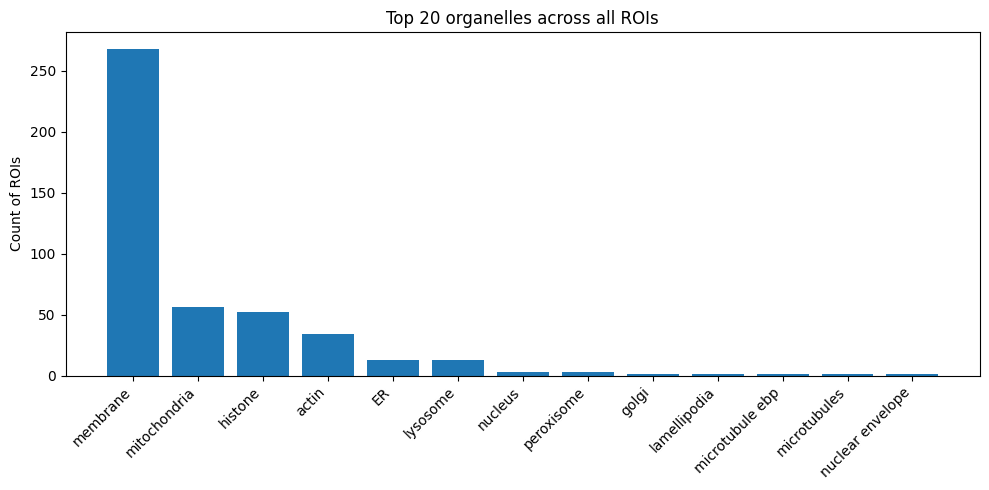

In [95]:
# CELL X1: Global organelle counts + bar plot

import matplotlib.pyplot as plt
import re
import math

def split_locs(val):
    if val is None or (isinstance(val, float) and math.isnan(val)):
        return []
    s = str(val).strip()
    if not s:
        return []
    toks = [t.strip() for t in re.split(r"[;,]", s) if t.strip()]
    return toks

org_rows = []
for _, row in df.iterrows():
    orgs = split_locs(row.get("all_unique_organelles"))
    for o in orgs:
        org_rows.append((o,))

df_org_summary = (
    pd.DataFrame(org_rows, columns=["organelle"])
      .value_counts()
      .reset_index(name="count")
      .sort_values("count", ascending=False)
)

display(df_org_summary)

# Plot top N organelles
topN = 20
top = df_org_summary.head(topN)

plt.figure(figsize=(10, 5))
plt.bar(top["organelle"], top["count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count of ROIs")
plt.title(f"Top {topN} organelles across all ROIs")
plt.tight_layout()
plt.show()

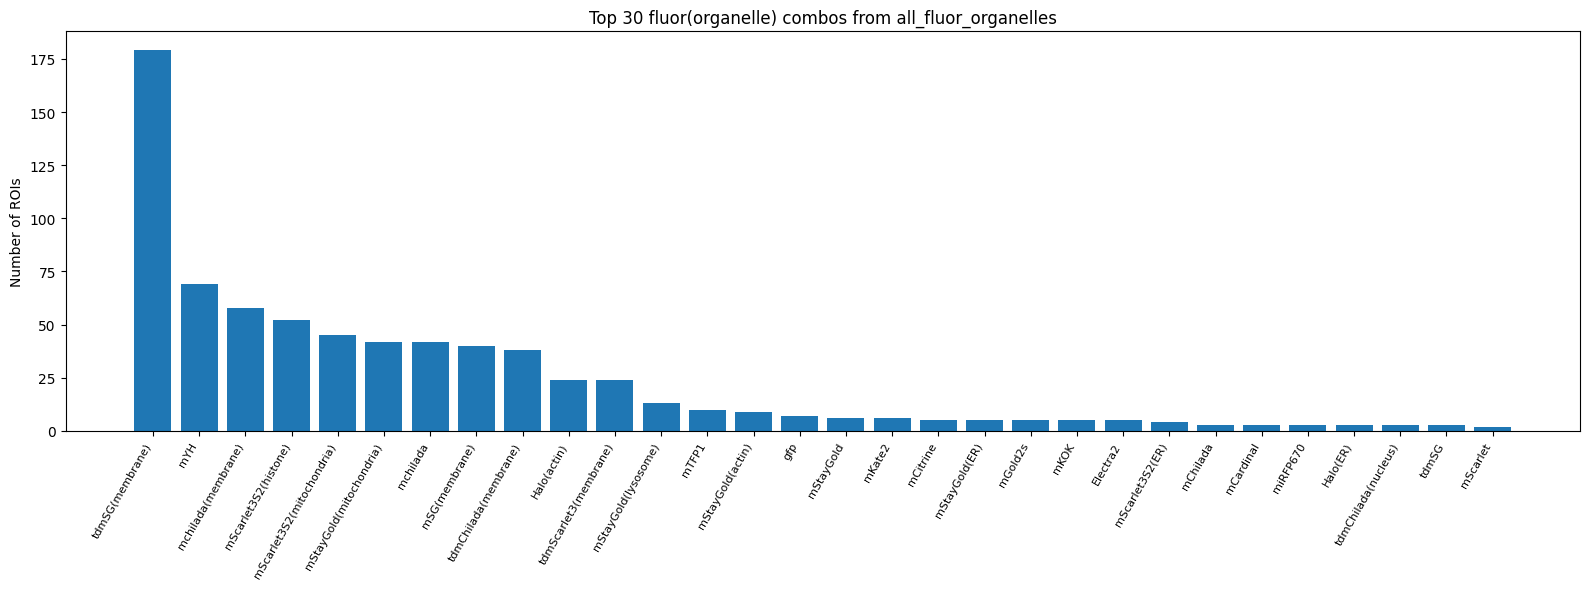

In [101]:
# Plot top N unique combos
topN = 30
top = df_fluor_org.head(topN)

if not top.empty:
    plt.figure(figsize=(16, 6))  # wider + taller
    plt.bar(top["fluor_org"], top["count"])
    plt.xticks(rotation=60, ha="right", fontsize=8)
    plt.ylabel("Number of ROIs")
    plt.title(f"Top {topN} fluor(organelle) combos from all_fluor_organelles")
    # explicitly pad bottom so labels aren't clipped
    plt.subplots_adjust(bottom=0.35)
    plt.tight_layout()
    plt.show()
else:
    print("No fluor-organelle combos found to plot.")